In [80]:
import numpy as np
import pandas as pd

df = pd.read_excel('Dataset.xlsx')
len(df)
df['GB_flag'].value_counts()

GB_flag
0    71936
1      570
Name: count, dtype: int64

In [81]:
desc = pd.read_excel('Variables_description.xlsx')

In [82]:
df.head(-5)
df[df['GB_flag'] == 1]

,total_amount_kzt,overdueinstalmentcount_po_subektu,term,GB_flag,was_canceled,GENDER,CLASSIFICATION,RESIDENCY,EDUCATION,MARITALSTATUS,...,AS3M,outstandingamount,overdueamount,instalmentamount,loans,frequency,monetary,recency,rfm_score,DTI3M
607,911321,NaN,1827,1,0,515.0,24.0,30.0,NaN,33.0,...,38774.04000,9.116555e+05,0.000000,58373.667380,2.0,5.0,1.606141e+06,34.0816,433.0,1.505483
766,1727428,NaN,1339,1,1,515.0,24.0,30.0,53.0,34.0,...,157587.00000,1.613281e+06,0.000000,49425.844574,1.0,3.0,5.687627e+06,55.3826,425.0,0.313642
783,1899853,0.0,1827,1,0,515.0,24.0,30.0,NaN,34.0,...,714121.80000,3.011494e+06,0.000000,103524.965264,1.0,4.0,5.505739e+06,19.1709,535.0,0.144968
1019,1080000,0.0,1096,1,0,516.0,24.0,30.0,NaN,NaN,...,98578.50000,0.000000e+00,0.000000,0.000000,1.0,2.0,2.719489e+05,476.8381,311.0,0.000000
1135,107527,0.0,182,1,0,515.0,24.0,30.0,NaN,NaN,...,79210.22685,1.500553e+05,0.000000,50.000606,2.0,3.0,1.860341e+06,7.9118,524.0,0.000631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63947,1300000,0.0,1095,1,0,515.0,24.0,30.0,53.0,34.0,...,NaN,3.760046e+04,0.000000,9400.286736,1.0,6.0,5.729631e+06,551.3916,345.0,NaN
64123,164000,0.0,546,1,0,515.0,24.0,30.0,NaN,NaN,...,113111.72000,0.000000e+00,0.000000,2838.161757,1.0,1.0,1.445302e+05,3014.7001,111.0,0.025092
65457,1737900,0.0,1826,1,0,515.0,24.0,30.0,NaN,33.0,...,NaN,3.861424e+06,0.000000,188285.985454,4.0,10.0,6.799358e+06,35.2988,445.0,NaN
65592,4409803,95.0,2434,1,0,515.0,24.0,30.0,NaN,34.0,...,NaN,1.802358e+07,720351.577064,477080.537803,5.0,8.0,2.325319e+07,528.2648,345.0,NaN


In [83]:
df.isnull().sum(axis = 0).sort_values()

total_amount_kzt         0
MONTH_OVERDUE_A15        0
MONTH_OVERDUE_A16        0
MONTH_OVERDUE_A17        0
MONTH_OVERDUE_A18        0
                     ...  
outstandingamount    49784
overdueamount        49784
instalmentamount     49784
DTI3M                57662
NEGATIVESTATUS       60267
Length: 177, dtype: int64

In [84]:
desc.head()
for i in range(len(desc)):
    print(desc.iloc[i])

GB_flag                                    total_amount_kzt
Флаг хороший/ плохой (таргет)    Сумма выдачи займа в тенге
Name: 0, dtype: object
GB_flag                                          overdueinstalmentcount_po_subektu
Флаг хороший/ плохой (таргет)    Макс. кол-во дней просрочки за все время по вс...
Name: 1, dtype: object
GB_flag                                                                 term
Флаг хороший/ плохой (таргет)    Продолжительность контракта при выдаче, дни
Name: 2, dtype: object
GB_flag                                                               was_canceled
Флаг хороший/ плохой (таргет)    Списывался у Физ.лица ли какой-либо займ до мо...
Name: 3, dtype: object
GB_flag                                GENDER
Флаг хороший/ плохой (таргет)    Пол заёмщика
Name: 4, dtype: object
GB_flag                                  CLASSIFICATION
Флаг хороший/ плохой (таргет)    Классификация Физ лица
Name: 5, dtype: object
GB_flag                            RESIDENCY
Флаг хо

In [85]:
df['NEGATIVESTATUS'].value_counts().sum()

12239

In [86]:
df['NEGATIVESTATUS'].isnull().sum()

60267

In [87]:
df.isnull().sum(axis = 0).sort_values() > len(df) * 0.2

total_amount_kzt     False
MONTH_OVERDUE_A15    False
MONTH_OVERDUE_A16    False
MONTH_OVERDUE_A17    False
MONTH_OVERDUE_A18    False
                     ...  
outstandingamount     True
overdueamount         True
instalmentamount      True
DTI3M                 True
NEGATIVESTATUS        True
Length: 177, dtype: bool

In [88]:
s = df.isnull().sum(axis = 0).sort_values() > len(df) * 0.2
s = s[s].index
s
data = df.drop(s, axis = 1)

In [89]:
s = (data.isnull().sum(axis = 0) > 0)
s = s[s]
data = data.drop(s.index, axis = 1)

In [90]:
data.isnull().sum().sum()

0

In [184]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data.drop(['GB_flag'], axis = 1), data['GB_flag'], test_size=0.2, random_state=1488, stratify = data['GB_flag'])

In [187]:
Train = pd.concat([X_train, y_train], axis = 1)

In [190]:
Train.isnull().sum().sum()

0

In [192]:
correlations = Train.corr()['GB_flag'].drop('GB_flag')

In [193]:
#################################################################
#        CORRELATION_THREASHOLD pretty arbitrary here
#################################################################
CORRELATION_THREASHOLD = 0.01
features = correlations[abs(correlations) > CORRELATION_THREASHOLD].index

In [194]:
features
print(len(features))

135


In [198]:
X = data[features]
y = data['GB_flag']

In [200]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1488, stratify = y)

In [202]:
pd.DataFrame(y_test).value_counts().sum()

14502

In [204]:
pd.DataFrame(y_train).value_counts().sum()

58004

In [206]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [208]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [210]:
model = LogisticRegression()
model.fit(X_train_sc, y_train)

# Make predictions
y_pred = model.predict(X_test_sc)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.99


C:\Users\1\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


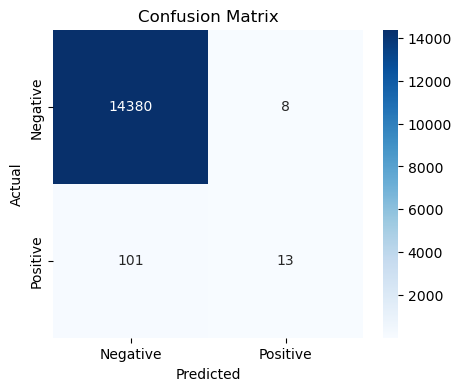

In [211]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred are already defined
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [214]:
# donnow if it is any good, apparently data itself is insanely skewed

In [216]:
X_test.to_csv('X_test_funky', index = False)
X_train.to_csv('X_train_funky', index = False)
y_test.to_csv('y_test_funky', index = False)
y_train.to_csv('y_train_funky', index = False)

In [217]:
import numpy as np
import pandas as pd


X_test = pd.read_csv('X_test_funky')
X_train = pd.read_csv('X_train_funky')
y_test = pd.read_csv('y_test_funky')
y_train = pd.read_csv('y_train_funky')

In [222]:
from catboost import CatBoostClassifier
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

# Define the model
model = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.01,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    early_stopping_rounds=20,
    verbose=2
)

# Train the model
model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# Predict probabilities
y_pred_prob = model.predict_proba(X_test)[:, 1]  # Get probability for class 1

# Compute AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
auc_pr = auc(recall, precision)

print(f"AUC-PR: {auc_pr:.4f}")

0:	test: 0.7546801	best: 0.7546801 (0)	total: 48.5ms	remaining: 4m 2s
2:	test: 0.7641471	best: 0.7711747 (1)	total: 100ms	remaining: 2m 47s
4:	test: 0.8014369	best: 0.8014369 (4)	total: 150ms	remaining: 2m 29s
6:	test: 0.8129451	best: 0.8129451 (6)	total: 201ms	remaining: 2m 23s
8:	test: 0.8054355	best: 0.8129451 (6)	total: 249ms	remaining: 2m 18s
10:	test: 0.8205147	best: 0.8205147 (10)	total: 299ms	remaining: 2m 15s
12:	test: 0.8217371	best: 0.8227781 (11)	total: 351ms	remaining: 2m 14s
14:	test: 0.8317128	best: 0.8317128 (14)	total: 403ms	remaining: 2m 14s
16:	test: 0.8300195	best: 0.8321512 (15)	total: 455ms	remaining: 2m 13s
18:	test: 0.8316467	best: 0.8321512 (15)	total: 505ms	remaining: 2m 12s
20:	test: 0.8300125	best: 0.8321512 (15)	total: 558ms	remaining: 2m 12s
22:	test: 0.8321853	best: 0.8321853 (22)	total: 610ms	remaining: 2m 12s
24:	test: 0.8323066	best: 0.8324953 (23)	total: 663ms	remaining: 2m 11s
26:	test: 0.8379924	best: 0.8379924 (26)	total: 716ms	remaining: 2m 11s
28

In [224]:
t = y_train == 0
t[t]

,GB_flag
0,True
1,True
2,True
3,True
4,True
...,...
57999,True
58000,True
58001,True
58002,True


In [226]:
y_train.value_counts()[0]
baseline_auc = y_train.value_counts()[1] / y_train.value_counts()[0]
baseline_auc

0.007923820115381942

In [228]:
import xgboost as xgb
from sklearn.metrics import precision_recall_curve, auc

# Define XGBoost parameters
params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "scale_pos_weight": y_train.value_counts()[0] / y_train.value_counts()[1],  # Adjust for class imbalance
    "learning_rate": 0.01,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 2,
    "lambda": 1,
    "alpha": 0.5,
    "min_child_weight": 10
}

# Convert dataset to XGBoost DMatrix format
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Train model
model = xgb.train(params, dtrain, num_boost_round=5000, 
                  evals=[(dtest, "test")], 
                  early_stopping_rounds=100, 
                  verbose_eval=200)

# Predict probabilities
y_pred_prob = model.predict(dtest)  # Get probability for class 1

# Compute AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
auc_pr = auc(recall, precision)

print(f"AUC-PR: {auc_pr:.4f}")

[0]	test-auc:0.80029
[148]	test-auc:0.88486
AUC-PR: 0.2226


In [230]:
import lightgbm as lgb
from sklearn.metrics import precision_recall_curve, auc

# Define LightGBM parameters
params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "is_unbalance": True,  # Alternatively, use scale_pos_weight
    "learning_rate": 0.01,
    "num_leaves": 31,
    "max_depth": -1,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 0.1,
    "lambda_l2": 0.1,
    "verbosity": -1
}

# Create LightGBM dataset
dtrain = lgb.Dataset(X_train, label=y_train)
dtest = lgb.Dataset(X_test, label=y_test, reference=dtrain)

# Train model
model = lgb.train(params, dtrain, num_boost_round=5000, 
                  valid_sets=[dtest])

# Predict probabilities
y_pred_prob = model.predict(X_test)  # Get probability for class 1

# Compute AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
auc_pr = auc(recall, precision)

print(f"AUC-PR: {auc_pr:.4f}")

AUC-PR: 0.2953
